# Regularización: Controlando el Overfitting

**Objetivo:** Entender qué es el overfitting, cómo detectarlo y las técnicas principales para combatirlo.

**Enfoque:**
- Visualizar el overfitting con curvas de entrenamiento
- Implementar L2, Dropout, Batch Normalization y Early Stopping
- Comparar modelos con y sin regularización

**Dataset:** Breast Cancer Wisconsin — el mismo del notebook anterior.

---

# Parte 1 — ¿Qué es el Overfitting?

Una red neuronal con muchos parámetros puede **memorizar** los datos de entrenamiento en vez de aprender los patrones generales. Cuando esto ocurre:

- El **loss de training** sigue bajando
- El **loss de validación** baja al principio pero luego **sube**

La brecha entre ambos es la señal de alarma. Regularización es cualquier técnica que reduce esa brecha.

---

## 1.1 Preparación de datos

Dividimos en tres conjuntos:
- **Train (64%):** para entrenar
- **Validation (16%):** para monitorear overfitting durante el entrenamiento
- **Test (20%):** para evaluar al final (solo se toca una vez)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target

# Primera división: separar test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Segunda división: separar validation (20% del restante = 16% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

# Normalizar (fit solo en train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train:      {X_train.shape[0]} muestras")
print(f"Validation: {X_val.shape[0]} muestras")
print(f"Test:       {X_test.shape[0]} muestras")
print(f"Features:   {X_train.shape[1]}")

Train:      364 muestras
Validation: 91 muestras
Test:       114 muestras
Features:   30


## 1.2 Provocando overfitting

Para ver el overfitting en acción, vamos a crear un modelo **intencionalmente grande** — muchas más neuronas de las necesarias para este dataset. Así la red tiene capacidad de sobra para memorizar.

In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

def crear_modelo_sin_regularizacion():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        Dense(64, activation='relu', kernel_initializer='he_normal'),
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_base = crear_modelo_sin_regularizacion()
modelo_base.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Entrenar por muchos epochs para ver el overfitting
historia_base = modelo_base.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=2
)

print("Entrenamiento completado.")

Epoch 1/100
12/12 - 0s - 11ms/step - accuracy: 1.0000 - loss: 1.9375e-05 - val_accuracy: 0.9670 - val_loss: 0.2180
Epoch 2/100
12/12 - 0s - 8ms/step - accuracy: 1.0000 - loss: 1.9212e-05 - val_accuracy: 0.9670 - val_loss: 0.2182
Epoch 3/100
12/12 - 0s - 8ms/step - accuracy: 1.0000 - loss: 1.8942e-05 - val_accuracy: 0.9670 - val_loss: 0.2184
Epoch 4/100
12/12 - 0s - 8ms/step - accuracy: 1.0000 - loss: 1.8678e-05 - val_accuracy: 0.9670 - val_loss: 0.2187
Epoch 5/100
12/12 - 0s - 10ms/step - accuracy: 1.0000 - loss: 1.8398e-05 - val_accuracy: 0.9670 - val_loss: 0.2189
Epoch 6/100
12/12 - 0s - 10ms/step - accuracy: 1.0000 - loss: 1.8143e-05 - val_accuracy: 0.9670 - val_loss: 0.2191
Epoch 7/100
12/12 - 0s - 9ms/step - accuracy: 1.0000 - loss: 1.7955e-05 - val_accuracy: 0.9670 - val_loss: 0.2193
Epoch 8/100
12/12 - 0s - 9ms/step - accuracy: 1.0000 - loss: 1.7674e-05 - val_accuracy: 0.9670 - val_loss: 0.2197
Epoch 9/100
12/12 - 0s - 9ms/step - accuracy: 1.0000 - loss: 1.7518e-05 - val_accurac

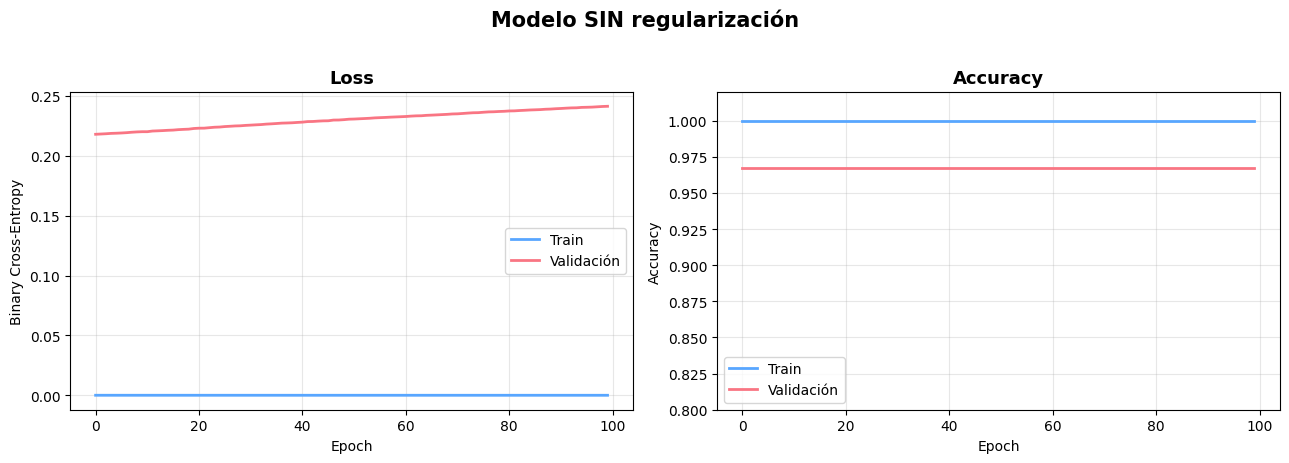

In [9]:
def graficar_historia(historia, titulo):
    """Grafica las curvas de loss y accuracy de entrenamiento vs validación."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    # Loss
    ax1.plot(historia.history['loss'], color='#58A6FF', linewidth=2, label='Train')
    ax1.plot(historia.history['val_loss'], color='#F97583', linewidth=2, label='Validación')
    ax1.set_title('Loss', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Cross-Entropy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(historia.history['accuracy'], color='#58A6FF', linewidth=2, label='Train')
    ax2.plot(historia.history['val_accuracy'], color='#F97583', linewidth=2, label='Validación')
    ax2.set_title('Accuracy', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0.8, 1.02)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle(titulo, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

graficar_historia(historia_base, 'Modelo SIN regularización')

Observa la brecha entre las curvas de train y validación. El loss de entrenamiento sigue bajando mientras que el de validación se estanca o sube — eso es **overfitting**.

---

# Parte 2 — Técnicas de Regularización

Ahora aplicaremos cada técnica para ver cómo reduce la brecha entre train y validación.

---

## 2.1 Regularización L2 (Weight Decay)

Agrega un castigo al loss proporcional al tamaño de los pesos:

$$\mathcal{L}_{total} = \mathcal{L}_{BCE} + \lambda \sum w_i^2$$

Esto fuerza a la red a mantener pesos pequeños, lo que produce un modelo más simple que generaliza mejor.

En Keras se aplica con el parámetro `kernel_regularizer` en cada capa.

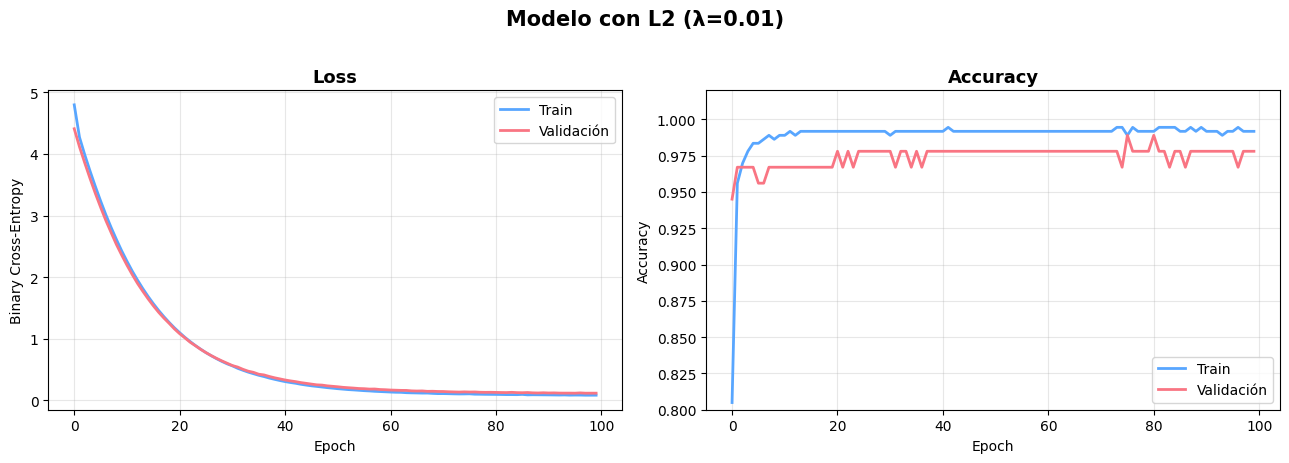

In [11]:
from tensorflow.keras.regularizers import l2

def crear_modelo_l2(lambda_l2=0.01):
    """Modelo con regularización L2 en todas las capas ocultas."""
    model = Sequential([
        Dense(128, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=l2(lambda_l2),
              input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=l2(lambda_l2)),
        Dense(32, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=l2(lambda_l2)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_l2 = crear_modelo_l2(lambda_l2=0.01)

historia_l2 = modelo_l2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)

graficar_historia(historia_l2, 'Modelo con L2 (λ=0.01)')

## 2.2 Dropout

En cada paso del entrenamiento, se "apagan" neuronas al azar con probabilidad $p$. Esto obliga a la red a distribuir el conocimiento entre todas las neuronas en vez de depender de unas pocas.

- Dropout se coloca **después** de la activación de cada capa oculta
- Durante evaluación/predicción, dropout se desactiva automáticamente
- Valores típicos: $p = 0.2$ a $0.5$

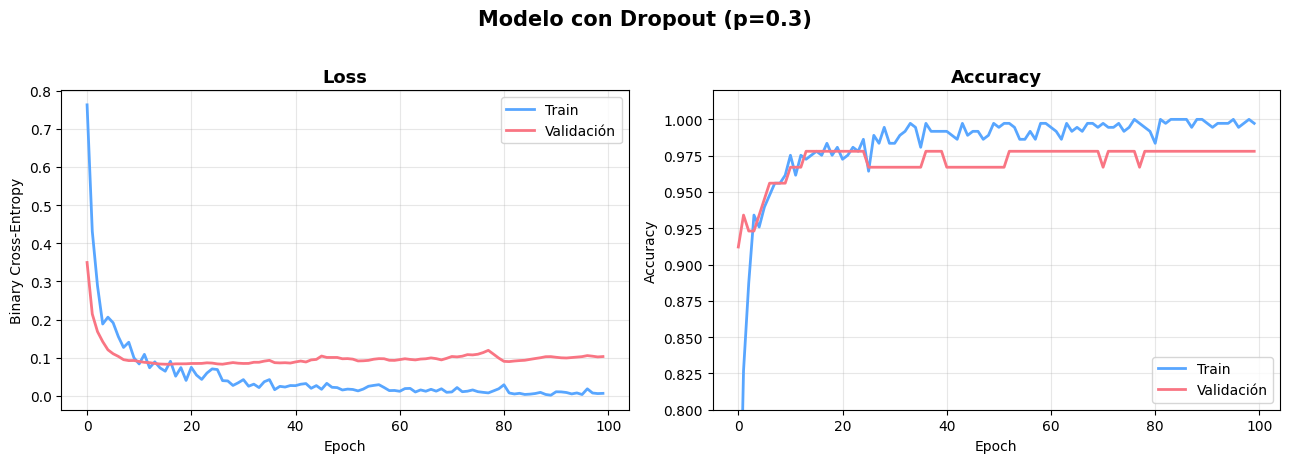

In [12]:
from tensorflow.keras.layers import Dropout

def crear_modelo_dropout(dropout_rate=0.3):
    """Modelo con Dropout después de cada capa oculta."""
    model = Sequential([
        Dense(128, activation='relu', kernel_initializer='he_normal',
              input_shape=(X_train.shape[1],)),
        Dropout(dropout_rate),

        Dense(64, activation='relu', kernel_initializer='he_normal'),
        Dropout(dropout_rate),

        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_dropout = crear_modelo_dropout(dropout_rate=0.3)

historia_dropout = modelo_dropout.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)

graficar_historia(historia_dropout, 'Modelo con Dropout (p=0.3)')

## 2.3 Batch Normalization

Normaliza las activaciones de cada capa dentro de cada mini-batch para mantener media ≈ 0 y std ≈ 1. Esto estabiliza el entrenamiento y actúa como regularizador leve.

Se coloca típicamente **entre la capa densa y la activación**, o justo después de la activación. Ambos enfoques funcionan; aquí lo ponemos después de la activación por simplicidad.

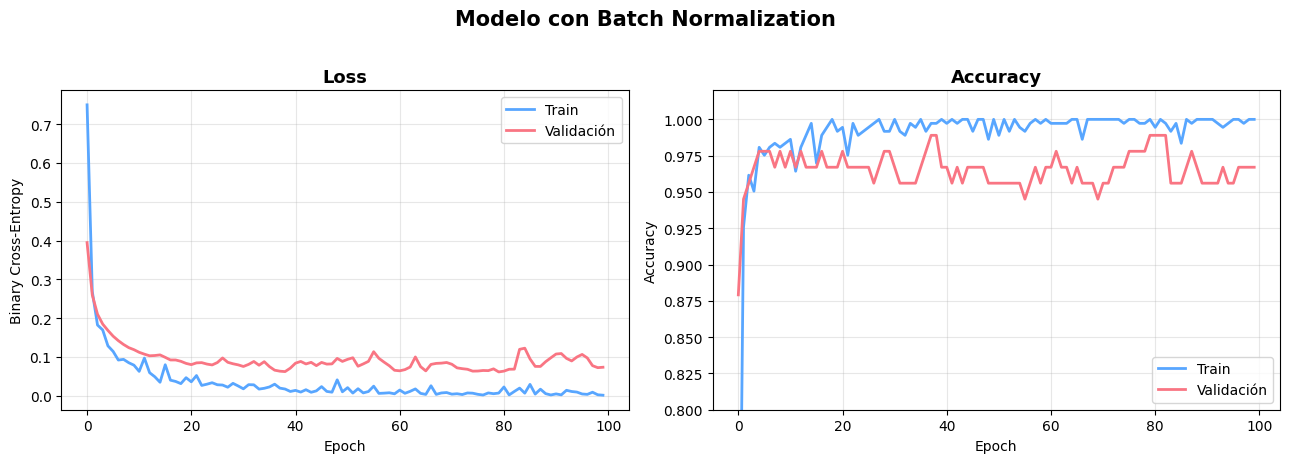

In [13]:
from tensorflow.keras.layers import BatchNormalization

def crear_modelo_batchnorm():
    """Modelo con Batch Normalization después de cada capa oculta."""
    model = Sequential([
        Dense(128, activation='relu', kernel_initializer='he_normal',
              input_shape=(X_train.shape[1],)),
        BatchNormalization(),

        Dense(64, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),

        Dense(32, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),

        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_bn = crear_modelo_batchnorm()

historia_bn = modelo_bn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)

graficar_historia(historia_bn, 'Modelo con Batch Normalization')

## 2.4 Early Stopping

Monitorea el loss de validación y detiene el entrenamiento cuando deja de mejorar. Restaura los pesos del mejor epoch.

- `monitor='val_loss'` — qué métrica vigilar
- `patience=15` — cuántos epochs sin mejora tolera antes de parar
- `restore_best_weights=True` — al final usa los pesos del mejor momento, no los últimos

Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 5.

Entrenamiento detenido en epoch 20


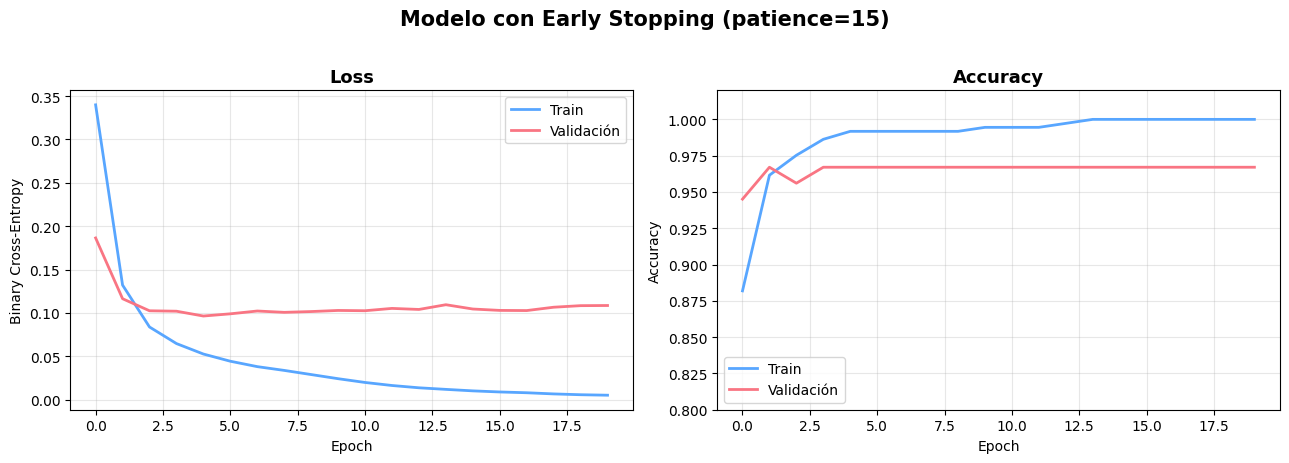

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Usamos el mismo modelo base (sin regularización)
# pero con early stopping para ver cuándo para
modelo_es = crear_modelo_sin_regularizacion()

historia_es = modelo_es.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

print(f"\nEntrenamiento detenido en epoch {len(historia_es.history['loss'])}")
graficar_historia(historia_es, 'Modelo con Early Stopping (patience=15)')

---

# Parte 3 — Combinando Técnicas

En la práctica, las técnicas se combinan. Un modelo típico usa:
- **Batch Normalization** para estabilizar el entrenamiento
- **Dropout** para prevenir overfitting
- **Early Stopping** como red de seguridad

Opcionalmente se agrega L2 si todavía hay overfitting.

Epoch 280: early stopping
Restoring model weights from the end of the best epoch: 260.

Entrenamiento detenido en epoch 280


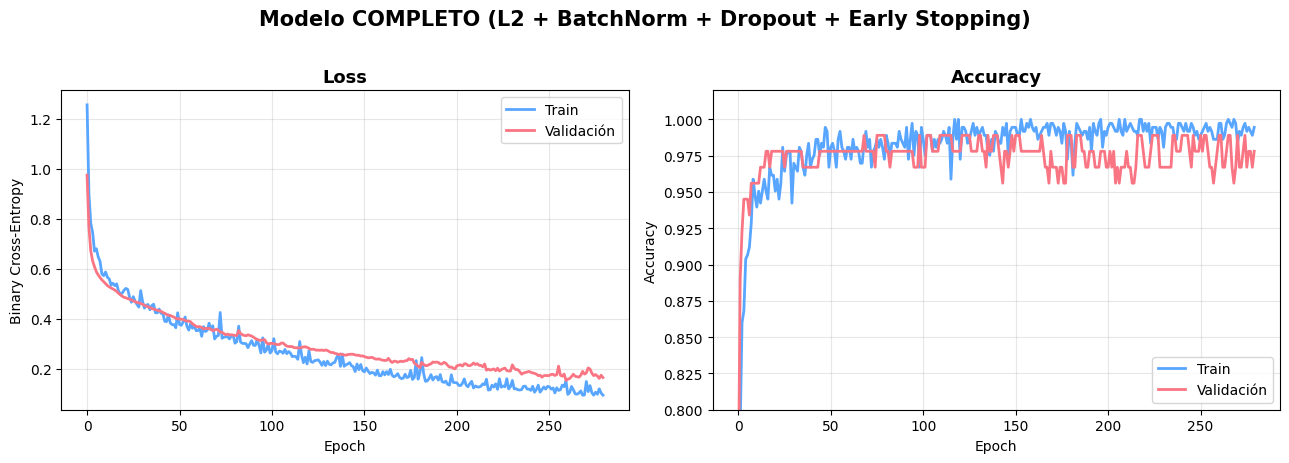

In [15]:
def crear_modelo_completo(dropout_rate=0.3, lambda_l2=0.001):
    """Modelo con todas las técnicas de regularización combinadas."""
    model = Sequential([
        # Capa 1
        Dense(128, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=l2(lambda_l2),
              input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Capa 2
        Dense(64, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=l2(lambda_l2)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Capa 3
        Dense(32, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=l2(lambda_l2)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Salida
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_completo = crear_modelo_completo()

early_stop_completo = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

historia_completa = modelo_completo.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_completo],
    verbose=0
)

print(f"\nEntrenamiento detenido en epoch {len(historia_completa.history['loss'])}")
graficar_historia(historia_completa, 'Modelo COMPLETO (L2 + BatchNorm + Dropout + Early Stopping)')

---

# Parte 4 — Comparación Final

Evaluamos todos los modelos en el conjunto de **test** (que ninguno vio durante el entrenamiento) para comparar su capacidad de generalización.

In [16]:
# Evaluar todos los modelos en test
modelos = {
    'Sin regularización': modelo_base,
    'L2 (λ=0.01)': modelo_l2,
    'Dropout (p=0.3)': modelo_dropout,
    'Batch Normalization': modelo_bn,
    'Early Stopping': modelo_es,
    'Completo (todas)': modelo_completo,
}

resultados = {}
print(f"{'Modelo':<25} {'Loss Test':>10} {'Acc Test':>10} {'Acc Train':>10}")
print("-" * 58)

for nombre, modelo in modelos.items():
    test_loss, test_acc = modelo.evaluate(X_test, y_test, verbose=0)
    train_loss, train_acc = modelo.evaluate(X_train, y_train, verbose=0)
    resultados[nombre] = {'test_loss': test_loss, 'test_acc': test_acc, 'train_acc': train_acc}
    print(f"{nombre:<25} {test_loss:>10.4f} {test_acc:>10.2%} {train_acc:>10.2%}")

Modelo                     Loss Test   Acc Test  Acc Train
----------------------------------------------------------
Sin regularización            0.1362     96.49%    100.00%
L2 (λ=0.01)                   0.1509     94.74%     99.45%
Dropout (p=0.3)               0.1882     96.49%    100.00%
Batch Normalization           0.1544     92.98%    100.00%
Early Stopping                0.1141     95.61%     99.18%
Completo (todas)              0.2181     95.61%    100.00%


### Comentarios de los resultados

**Lo esperado:**

* El modelo sin regularización tiene 100% en train pero baja en test → overfitting claro, la brecha de ~3.5% confirma que memoriza
* Early Stopping tiene el mejor loss de test (0.1141) y redujo la brecha → funciona como se espera
* L2 redujo el train accuracy a 99.45% → está efectivamente limitando la capacidad del modelo

* El modelo "Completo" tiene el peor loss (0.2181) a pesar de combinar todo. Esto pasa cuando hay demasiada regularización para un dataset pequeño y relativamente fácil. Breast Cancer tiene solo 569 muestras y las clases son bastante separables, entonces no necesita tanta regularización.
* Batch Norm bajó a 92.98% en test, lo cual sugiere que en este caso particular no ayuda (con datasets pequeños y batches pequeños, BatchNorm puede ser inestable).

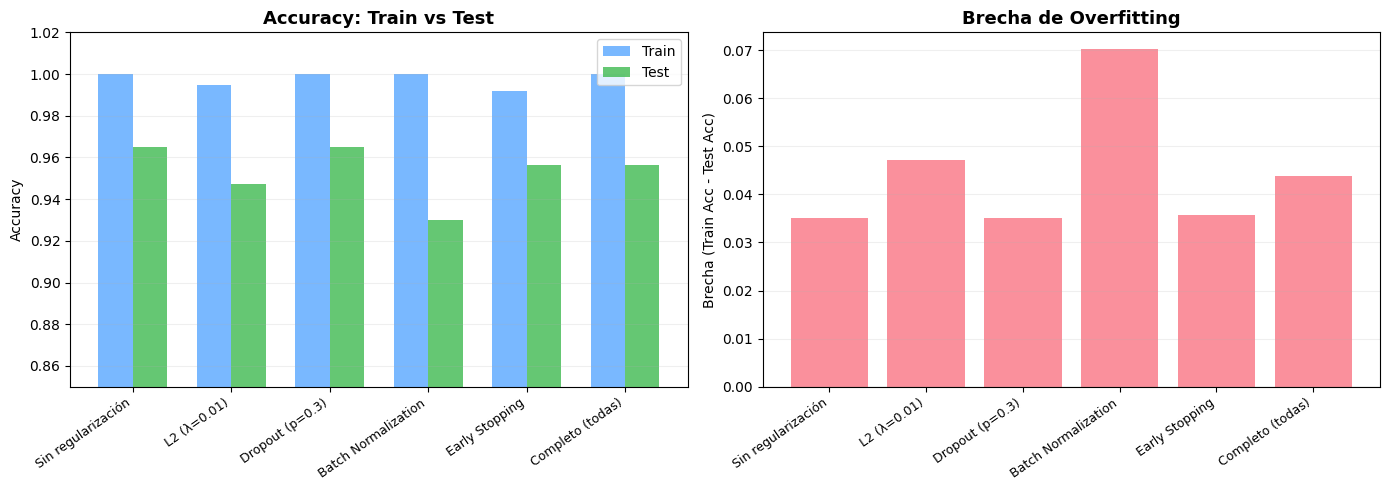

In [17]:
# --- Gráfica comparativa ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

nombres = list(resultados.keys())
test_accs = [resultados[n]['test_acc'] for n in nombres]
train_accs = [resultados[n]['train_acc'] for n in nombres]
test_losses = [resultados[n]['test_loss'] for n in nombres]

x_pos = np.arange(len(nombres))
ancho = 0.35

# Accuracy: Train vs Test
bars1 = ax1.bar(x_pos - ancho/2, train_accs, ancho, label='Train', color='#58A6FF', alpha=0.8)
bars2 = ax1.bar(x_pos + ancho/2, test_accs, ancho, label='Test', color='#3FB950', alpha=0.8)
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy: Train vs Test', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(nombres, rotation=35, ha='right', fontsize=9)
ax1.legend()
ax1.set_ylim(0.85, 1.02)
ax1.grid(True, alpha=0.2, axis='y')

# Brecha (gap) entre train y test accuracy
gaps = [train_accs[i] - test_accs[i] for i in range(len(nombres))]
colores_gap = ['#F97583' if g > 0.03 else '#3FB950' for g in gaps]
ax2.bar(x_pos, gaps, color=colores_gap, alpha=0.8)
ax2.set_ylabel('Brecha (Train Acc - Test Acc)')
ax2.set_title('Brecha de Overfitting', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(nombres, rotation=35, ha='right', fontsize=9)
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

---

# Parte 5 — Regularización desde cero con NumPy

Para entender qué pasa por dentro, implementemos **L2** y **Dropout** a mano.

---

In [18]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [19]:
# ============================================================
# TRAINING LOOP CON L2 + DROPOUT
# ============================================================
np.random.seed(42)

n_features = X_train.shape[1]  # 30
n_hidden = 32
n_output = 1

# Inicializar pesos
W1 = np.random.randn(n_hidden, n_features) * np.sqrt(2.0 / n_features)
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_output, n_hidden) * np.sqrt(1.0 / n_hidden)
b2 = np.zeros((1, n_output))

# Hiperparámetros
lr = 0.01
epochs = 200
lambda_l2 = 0.01     # fuerza de regularización L2
dropout_rate = 0.3    # probabilidad de apagar cada neurona

# Reshape targets
y_tr = y_train.reshape(-1, 1).astype(np.float64)
y_v = y_val.reshape(-1, 1).astype(np.float64)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    B = X_train.shape[0]

    # ========================
    # 1. FORWARD (con Dropout)
    # ========================
    Z1 = X_train @ W1.T + b1
    A1 = relu(Z1)

    # Dropout: crear máscara aleatoria y escalar
    # Escalamos por 1/(1-p) para que la media de las activaciones no cambie
    mask1 = (np.random.rand(*A1.shape) > dropout_rate).astype(float)
    mask1 /= (1 - dropout_rate)  # inverted dropout
    A1_dropped = A1 * mask1

    Z2 = A1_dropped @ W2.T + b2
    A2 = sigmoid(Z2)

    # ========================
    # 2. LOSS (BCE + L2)
    # ========================
    bce_loss = binary_cross_entropy(A2, y_tr)
    # Término L2: λ * (suma de todos los pesos al cuadrado)
    l2_penalty = lambda_l2 * (np.sum(W1**2) + np.sum(W2**2))
    total_loss = bce_loss + l2_penalty
    train_losses.append(total_loss)

    # Accuracy
    train_acc = np.mean((A2 >= 0.5).astype(float) == y_tr)
    train_accs.append(train_acc)

    # ========================
    # 3. BACKPROPAGATION
    # ========================
    dZ2 = (A2 - y_tr) / B
    dW2 = dZ2.T @ A1_dropped + 2 * lambda_l2 * W2   # ← L2 agrega 2λW al gradiente
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2
    dA1 *= mask1                                      # ← Dropout: solo propaga por neuronas activas
    dZ1 = dA1 * relu_deriv(Z1)

    dW1 = dZ1.T @ X_train + 2 * lambda_l2 * W1       # ← L2 agrega 2λW al gradiente
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ========================
    # 4. ACTUALIZAR PESOS
    # ========================
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    # ========================
    # VALIDACIÓN (sin dropout)
    # ========================
    Z1_val = X_val @ W1.T + b1
    A1_val = relu(Z1_val)        # sin dropout ni escalado
    Z2_val = A1_val @ W2.T + b2
    A2_val = sigmoid(Z2_val)

    val_loss = binary_cross_entropy(A2_val, y_v) + lambda_l2 * (np.sum(W1**2) + np.sum(W2**2))
    val_losses.append(val_loss)
    val_acc = np.mean((A2_val >= 0.5).astype(float) == y_v)
    val_accs.append(val_acc)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3d}  |  Train Loss: {total_loss:.4f}  Acc: {train_acc:.2%}  |  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2%}")

Epoch  50  |  Train Loss: 1.0807  Acc: 83.24%  |  Val Loss: 1.0389  Acc: 91.21%
Epoch 100  |  Train Loss: 0.9411  Acc: 90.93%  |  Val Loss: 0.9018  Acc: 93.41%
Epoch 150  |  Train Loss: 0.8818  Acc: 89.56%  |  Val Loss: 0.8412  Acc: 93.41%
Epoch 200  |  Train Loss: 0.8363  Acc: 92.31%  |  Val Loss: 0.8028  Acc: 95.60%


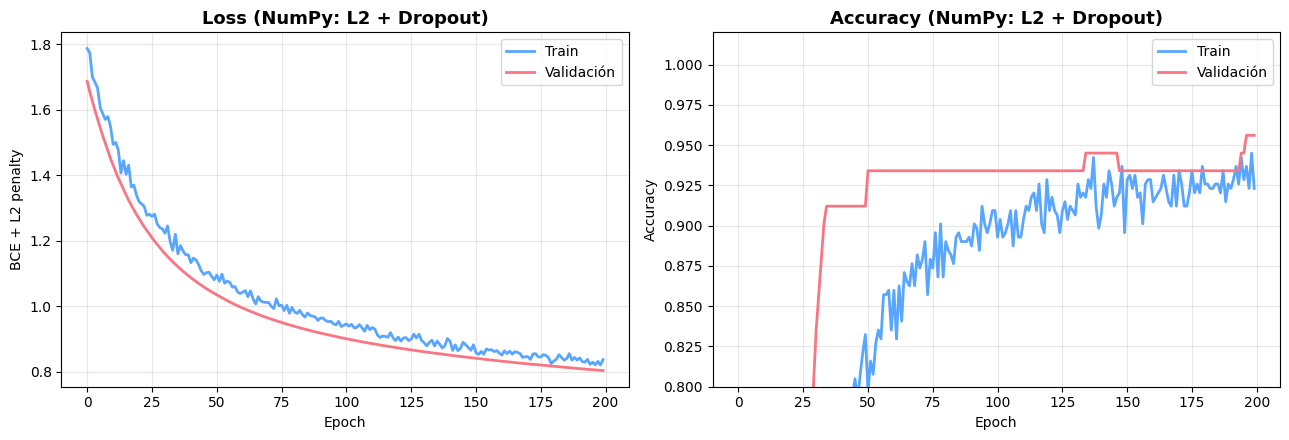


Resultados NumPy (L2 + Dropout) en Test:
  Loss:     0.2251
  Accuracy: 96.49%


In [20]:
# --- Gráficas del modelo NumPy ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(train_losses, color='#58A6FF', linewidth=2, label='Train')
ax1.plot(val_losses, color='#F97583', linewidth=2, label='Validación')
ax1.set_title('Loss (NumPy: L2 + Dropout)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE + L2 penalty')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, color='#58A6FF', linewidth=2, label='Train')
ax2.plot(val_accs, color='#F97583', linewidth=2, label='Validación')
ax2.set_title('Accuracy (NumPy: L2 + Dropout)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.8, 1.02)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluar en test (sin dropout)
y_te = y_test.reshape(-1, 1).astype(np.float64)
Z1_te = X_test @ W1.T + b1
A1_te = relu(Z1_te)
Z2_te = A1_te @ W2.T + b2
A2_te = sigmoid(Z2_te)

test_acc_np = np.mean((A2_te >= 0.5).astype(float) == y_te)
test_loss_np = binary_cross_entropy(A2_te, y_te)
print(f"\nResultados NumPy (L2 + Dropout) en Test:")
print(f"  Loss:     {test_loss_np:.4f}")
print(f"  Accuracy: {test_acc_np:.2%}")

---

## Reflexión final

### Lo que vimos en este notebook

1. **Overfitting** se detecta comparando train vs validación — cuando la brecha crece, el modelo está memorizando
2. **L2** castiga pesos grandes, forzando soluciones más simples. En el gradiente agrega $2\lambda W$
3. **Dropout** apaga neuronas al azar durante el entrenamiento, distribuyendo el conocimiento. En el backprop solo propaga gradientes por las neuronas activas
4. **Batch Normalization** normaliza las activaciones internas, estabilizando el entrenamiento
5. **Early Stopping** detiene el entrenamiento cuando la validación deja de mejorar
6. **Combinar técnicas** suele dar los mejores resultados

### Patrón típico de una capa regularizada

```
Dense → BatchNormalization → Dropout
```

Este patrón se repite por cada capa oculta, y la capa de salida no lleva ni Dropout ni BatchNorm.